<h2>Case Study 1 – Data De-identification & Exploratory Data Analysis (EDA)</h2>

<h4>1. Load and Inspect the Data</h4>

In [1]:
#Import Libaries
import pandas as pd
import numpy as np
import re
import hashlib
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("covid_clinical_notes_synthetic.csv")

In [3]:
# Inspect the data
df.head()
df.info() 
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         300 non-null    object 
 1   encounter_id       300 non-null    object 
 2   patient_name       300 non-null    object 
 3   age                300 non-null    int64  
 4   sex                300 non-null    object 
 5   city               300 non-null    object 
 6   zip_code           300 non-null    int64  
 7   phone_number       300 non-null    object 
 8   admission_date     300 non-null    object 
 9   discharge_date     300 non-null    object 
 10  hospital_name      300 non-null    object 
 11  provider_name      300 non-null    object 
 12  covid_test_result  300 non-null    object 
 13  icu_admission      300 non-null    object 
 14  oxygen_saturation  300 non-null    float64
 15  temperature_c      300 non-null    float64
 16  comorbidities      300 non

patient_id           0
encounter_id         0
patient_name         0
age                  0
sex                  0
city                 0
zip_code             0
phone_number         0
admission_date       0
discharge_date       0
hospital_name        0
provider_name        0
covid_test_result    0
icu_admission        0
oxygen_saturation    0
temperature_c        0
comorbidities        0
note_text            0
dtype: int64

This dataset contains synthetic COVID-19 clinical encounter records, including patient demographics, hospital and provider information, test results, ICU admission status, vital signs, comorbidities, and semi-structured clinical notes. Each row represents one patient encounter rather than a unique patient. Initial inspection shows no missing values; however, the dataset includes several sensitive identifiers such as patient names, phone numbers, ZIP codes, provider and hospital names, and free-text clinical notes that may embed identifiable information. These characteristics make privacy protection necessary before conducting meaningful analysis.

<h5>2. De-identify PII </h5>

In [4]:
#Identify all direct identifiers and quasi-identifiers
pii_patterns = {
    "phone": r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b",
    "zip": r"\b\d{5}\b"
}

def contains_pii(text):
    for pattern in pii_patterns.values():
        if re.search(pattern, str(text)):
            return True
    return False
#Search for PII inside note_text
df["note_contains_pii"] = df["note_text"].apply(contains_pii)
df["note_contains_pii"].value_counts()

note_contains_pii
True    300
Name: count, dtype: int64

In [5]:
#Create a table showing: Name of column, Direct or quasi-identifier
#Create a cleaned dataset called df_clean
df_clean = df.copy()

# Hash function for IDs
def hash_id(val):
    return hashlib.sha256(str(val).encode()).hexdigest()

# Hash identifiers
df_clean["patient_id"] = df_clean["patient_id"].apply(hash_id)
df_clean["encounter_id"] = df_clean["encounter_id"].apply(hash_id)

# Mask ZIP code
df_clean["zip_code"] = df_clean["zip_code"].astype(str).str[:3] + "XX"

# Convert dates to year only
df_clean["admission_year"] = pd.to_datetime(df_clean["admission_date"]).dt.year
df_clean["discharge_year"] = pd.to_datetime(df_clean["discharge_date"]).dt.year

# Drop sensitive columns
df_clean = df_clean.drop(columns=[
    "patient_name",
    "phone_number",
    "provider_name",
    "note_text",
    "admission_date",
    "discharge_date"
])

df_clean.head(10)

,patient_id,encounter_id,age,sex,city,zip_code,hospital_name,covid_test_result,icu_admission,oxygen_saturation,temperature_c,comorbidities,note_contains_pii,admission_year,discharge_year
0,11c47747d69a7aa72735cd7d68853b0685b2bdd47113cc...,3225ef32040623e700463ffcd14006711ff5ebb524bf86...,69,Other,Pasadena,915XX,St. Mary's Medical Center,Negative,No,95.5,37.1,copd;hypertension,True,2020,2020
1,11c47747d69a7aa72735cd7d68853b0685b2bdd47113cc...,69050a418734442c99d69f8af69717668620e83172e1f4...,41,Male,Glendale,912XX,North Hills Clinic,Positive,Yes,92.9,38.3,diabetes,True,2020,2020
2,11c47747d69a7aa72735cd7d68853b0685b2bdd47113cc...,c1b3b5c1cf1d5a810aec1bcff1217a953f6d74f7cc9d38...,81,Male,Los Angeles,904XX,Valley General Hospital,Positive,No,92.1,37.9,obesity,True,2020,2020
3,25398f74e67831fb0204fb66b02290a73c39ecd05c4b86...,4ba60d18bd08cdc99c642a00b3d6ccec3de01fdebe27fa...,77,Female,Glendale,912XX,Eastside Community Hospital,Negative,No,96.0,37.4,asthma;hypertension;none,True,2020,2020
4,25398f74e67831fb0204fb66b02290a73c39ecd05c4b86...,4c110629805afe7d7c3f99a8b2669ae114ac8725247866...,68,Female,Glendale,904XX,North Hills Clinic,Negative,No,91.9,37.8,hypertension,True,2020,2020
5,25398f74e67831fb0204fb66b02290a73c39ecd05c4b86...,00d22f7dc67dbadf3f1386fc2a15a6eb149e7ad440881c...,70,Male,Burbank,912XX,Westbrook Medical Center,Negative,Yes,97.9,38.0,diabetes;obesity,True,2020,2020
6,4f7a734462e000a76300d3180ae0afc13c6adf6f41cf4c...,970f7160c1885aad8578c3d6a0286581f1f43b04ee21fa...,53,Other,Pasadena,908XX,North Hills Clinic,Positive,No,86.5,38.0,asthma;none,True,2020,2020
7,4f7a734462e000a76300d3180ae0afc13c6adf6f41cf4c...,25bfe54442a1c178498f6aebffa0adfc8ffb400f32537f...,71,Male,Long Beach,911XX,St. Mary's Medical Center,Positive,No,95.0,38.3,diabetes;hypertension,True,2020,2020
8,4f7a734462e000a76300d3180ae0afc13c6adf6f41cf4c...,b95887d8e1955ad6f3b341d7595eca23548ef6a620ac3e...,79,Male,Long Beach,900XX,Valley General Hospital,Positive,No,95.1,37.8,ckd,True,2020,2020
9,e99905cdf494500c4ef432254ae45e7fad0025e0145e4e...,afefffc5ace34561caedd87be4d40190c00c9ec0551686...,77,Female,Long Beach,904XX,Eastside Community Hospital,Pending,No,92.2,36.5,copd;diabetes,True,2020,2020


The cleaned dataset removes all direct identifiers and reduces re-identification risk by hashing IDs, masking ZIP codes, generalizing dates to year level, and removing free-text clinical notes that may contain embedded PII. These steps preserve analytical value while protecting patient privacy.

<h5>3.Exploratory Data Analysis (EDA) — Use df_clean Only</h5>

<h6>Summary statistics:Numerical Variable</h6>

In [6]:
df_clean.describe()

,age,oxygen_saturation,temperature_c,admission_year,discharge_year
count,300.000000,300.000000,300.000000,300.0,300.0
mean,53.073333,93.624333,37.722000,2020.0,2020.0
std,20.303087,4.009417,0.781592,0.0,0.0
min,18.000000,82.200000,36.000000,2020.0,2020.0
25%,35.000000,91.075000,37.200000,2020.0,2020.0
50%,53.000000,93.750000,37.700000,2020.0,2020.0
75%,69.250000,96.600000,38.200000,2020.0,2020.0
max,89.000000,105.500000,40.000000,2020.0,2020.0


<h6>Summary statistics:Categorial Variable</h6>

In [7]:
df_clean["sex"].value_counts()

sex
Female    115
Male       96
Other      89
Name: count, dtype: int64

In [8]:
df_clean["icu_admission"].value_counts()

icu_admission
No     217
Yes     83
Name: count, dtype: int64

In [9]:
df_clean["covid_test_result"].value_counts()

covid_test_result
Positive    165
Negative    107
Pending      28
Name: count, dtype: int64

The summary statistics show the distribution of numerical variables such as age, oxygen saturation, and body temperature, including their central tendency and spread. Value counts for categorical variables help us understand class balance, such as the proportion of ICU admissions and COVID-positive versus negative test results.

<h6>Visualizations</h6>

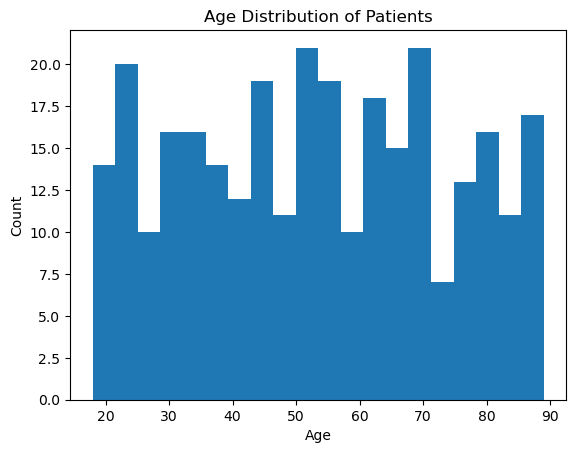

In [10]:
plt.figure()
plt.hist(df_clean["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Patients")
plt.show()

This histogram shows the age distribution of patients in the dataset. Most patient encounters fall within the middle-age to older-adult range, which is consistent with higher clinical attention for COVID-related cases.

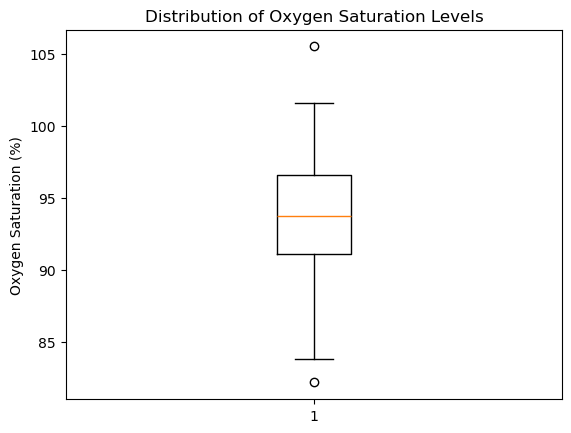

In [11]:
plt.figure()
plt.boxplot(df_clean["oxygen_saturation"])
plt.ylabel("Oxygen Saturation (%)")
plt.title("Distribution of Oxygen Saturation Levels")
plt.show()

The boxplot summarizes the spread and central tendency of oxygen saturation levels. It highlights potential low outliers, which may indicate patients experiencing respiratory distress.

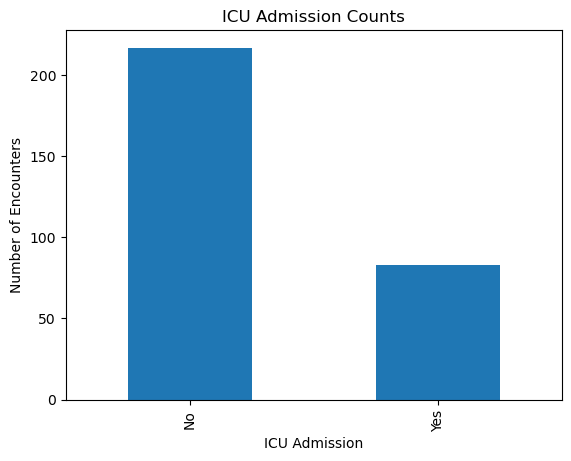

In [12]:
plt.figure()
df_clean["icu_admission"].value_counts().plot(kind="bar")
plt.xlabel("ICU Admission")
plt.ylabel("Number of Encounters")
plt.title("ICU Admission Counts")
plt.show()

This bar chart compares the number of encounters with and without ICU admission. It shows that most patients were not admitted to the ICU, suggesting severe cases are less frequent than non-severe cases.

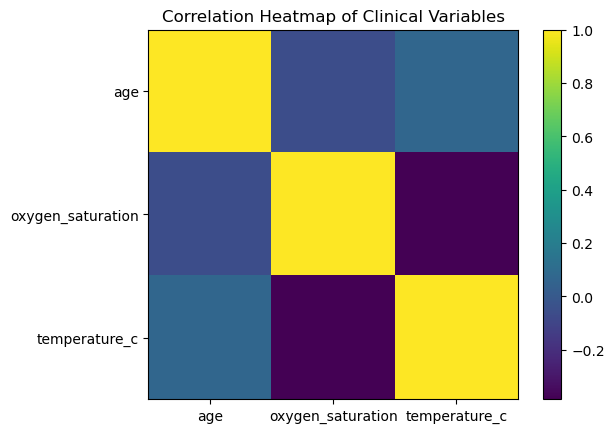

In [13]:
corr = df_clean[["age", "oxygen_saturation", "temperature_c"]].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Clinical Variables")
plt.show()

The correlation heatmap shows the relationships between age, oxygen saturation, and temperature. Oxygen saturation appears weakly correlated with age, while temperature shows minimal correlation with other variables.

<h5>4.Finding</h5>

The EDA shows that patient ages span a broad adult range, roughly from early adulthood to older age, with most encounters concentrated in middle-aged and older patients. Oxygen saturation values are generally high, clustering around the mid to high 90% range, with a small number of lower values indicating potential respiratory distress. Body temperature values fall within a clinically realistic range, mostly near normal body temperature with few elevated readings. ICU admissions represent a minority of encounters, while most patients test positive for COVID-19. No extreme or implausible values were observed after de-identification, suggesting that the cleaned dataset preserves meaningful clinical patterns while protecting patient privacy.

<h5>5.Reflection</h5>

De-identification reduced some data richness, particularly by removing free-text clinical notes and detailed location and date information. However, the cleaned dataset remains useful for meaningful analysis, such as identifying trends in age, vital signs, COVID outcomes, and ICU admissions. Generalizing dates and masking geographic details helped balance privacy protection with analytical value. </BR>

Privacy regulations such as HIPAA and FERPA are essential because they protect individuals from re-identification, discrimination, and misuse of sensitive personal information. In real-world data work, especially in healthcare and education, these regulations ensure ethical data handling, build public trust, and allow organizations to responsibly use data for research and decision-making while safeguarding individual rights.